## Exploratory Data Analysis

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FEATURE_COLUMNS, RAW_DATA_PATH, TARGET_COLUMN

df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
df.head()

(55000, 19)


,relationship_days,cash_purchase_value_last_30d,credit_purchase_value_last_30d,transaction_count_last_30d,credit_transaction_count_last_30d,avg_purchase_amount,avg_credit_transaction_amount,credit_to_purchase_ratio,current_outstanding_balance,outstanding_to_avg_transaction_ratio,pct_repaid_on_time,avg_days_to_repay,repayment_consistency,historical_repayment_ratio,num_completed_credit_cycles,num_severely_late_repayments,max_outstanding_ever,days_since_last_purchase,is_risk
0,693,0.00,1635.44,2,2,827.67,712.90,0.3661,0.00,0.0000,0.9412,8.57,9.81,1.000,17,1,1666.71,19,0
1,256,148.67,474.87,4,3,199.05,221.79,0.3277,164.18,0.7402,0.4444,36.14,34.90,0.926,9,3,725.15,11,0
2,240,4208.26,5437.40,8,4,1135.77,1177.02,0.3337,4136.77,3.5146,0.8235,10.61,13.41,0.815,17,2,4838.47,1,0
3,523,0.00,112.99,1,1,318.42,332.85,0.2543,0.00,0.0000,0.6667,11.92,8.42,1.000,9,0,880.76,33,0
4,921,1224.81,246.62,4,1,409.07,418.99,0.1585,-0.00,-0.0000,0.9231,9.31,13.00,1.000,13,1,1233.02,10,0


In [2]:
# Schema / dtype / missingness check
df.info()
print("\nMissing values per column:")
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   relationship_days                     55000 non-null  int64  
 1   cash_purchase_value_last_30d          55000 non-null  float64
 2   credit_purchase_value_last_30d        55000 non-null  float64
 3   transaction_count_last_30d            55000 non-null  int64  
 4   credit_transaction_count_last_30d     55000 non-null  int64  
 5   avg_purchase_amount                   55000 non-null  float64
 6   avg_credit_transaction_amount         55000 non-null  float64
 7   credit_to_purchase_ratio              55000 non-null  float64
 8   current_outstanding_balance           55000 non-null  float64
 9   outstanding_to_avg_transaction_ratio  55000 non-null  float64
 10  pct_repaid_on_time                    55000 non-null  float64
 11  avg_days_to_rep

is_risk prevalence: 13.90%


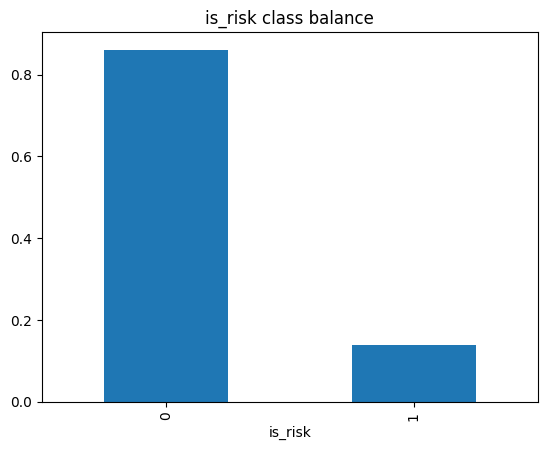

In [3]:
# Class balance
prevalence = df[TARGET_COLUMN].mean()
print(f"is_risk prevalence: {prevalence:.2%}")
df[TARGET_COLUMN].value_counts(normalize=True).plot(kind="bar", title="is_risk class balance")
plt.show()

In [4]:
# Descriptive statistics
df[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
relationship_days,55000.0,269.310691,250.321102,7.0000,90.0000,180.00000,362.000000,1446.0000
cash_purchase_value_last_30d,55000.0,2600.143098,3473.554875,0.0000,467.4925,1301.68000,3261.195000,27088.8800
credit_purchase_value_last_30d,55000.0,1389.635786,1782.819341,20.0000,327.1650,750.14500,1695.092500,18640.0800
transaction_count_last_30d,55000.0,11.134727,8.106495,1.0000,5.0000,8.00000,18.000000,31.0000
credit_transaction_count_last_30d,55000.0,3.862582,3.000316,1.0000,2.0000,3.00000,5.000000,20.0000
avg_purchase_amount,55000.0,358.989056,269.414478,35.6400,134.9500,267.60500,523.460000,1642.5100
avg_credit_transaction_amount,55000.0,360.863205,279.757492,36.3900,135.1875,265.02500,519.595000,2188.6700
credit_to_purchase_ratio,55000.0,0.300859,0.148717,0.0120,0.1878,0.28200,0.392400,1.0000
current_outstanding_balance,55000.0,537.683811,1017.508414,-0.0000,0.0000,131.09000,620.280000,15490.8200
outstanding_to_avg_transaction_ratio,55000.0,1.516866,2.109136,-0.0000,0.0000,0.70465,2.273325,16.9495


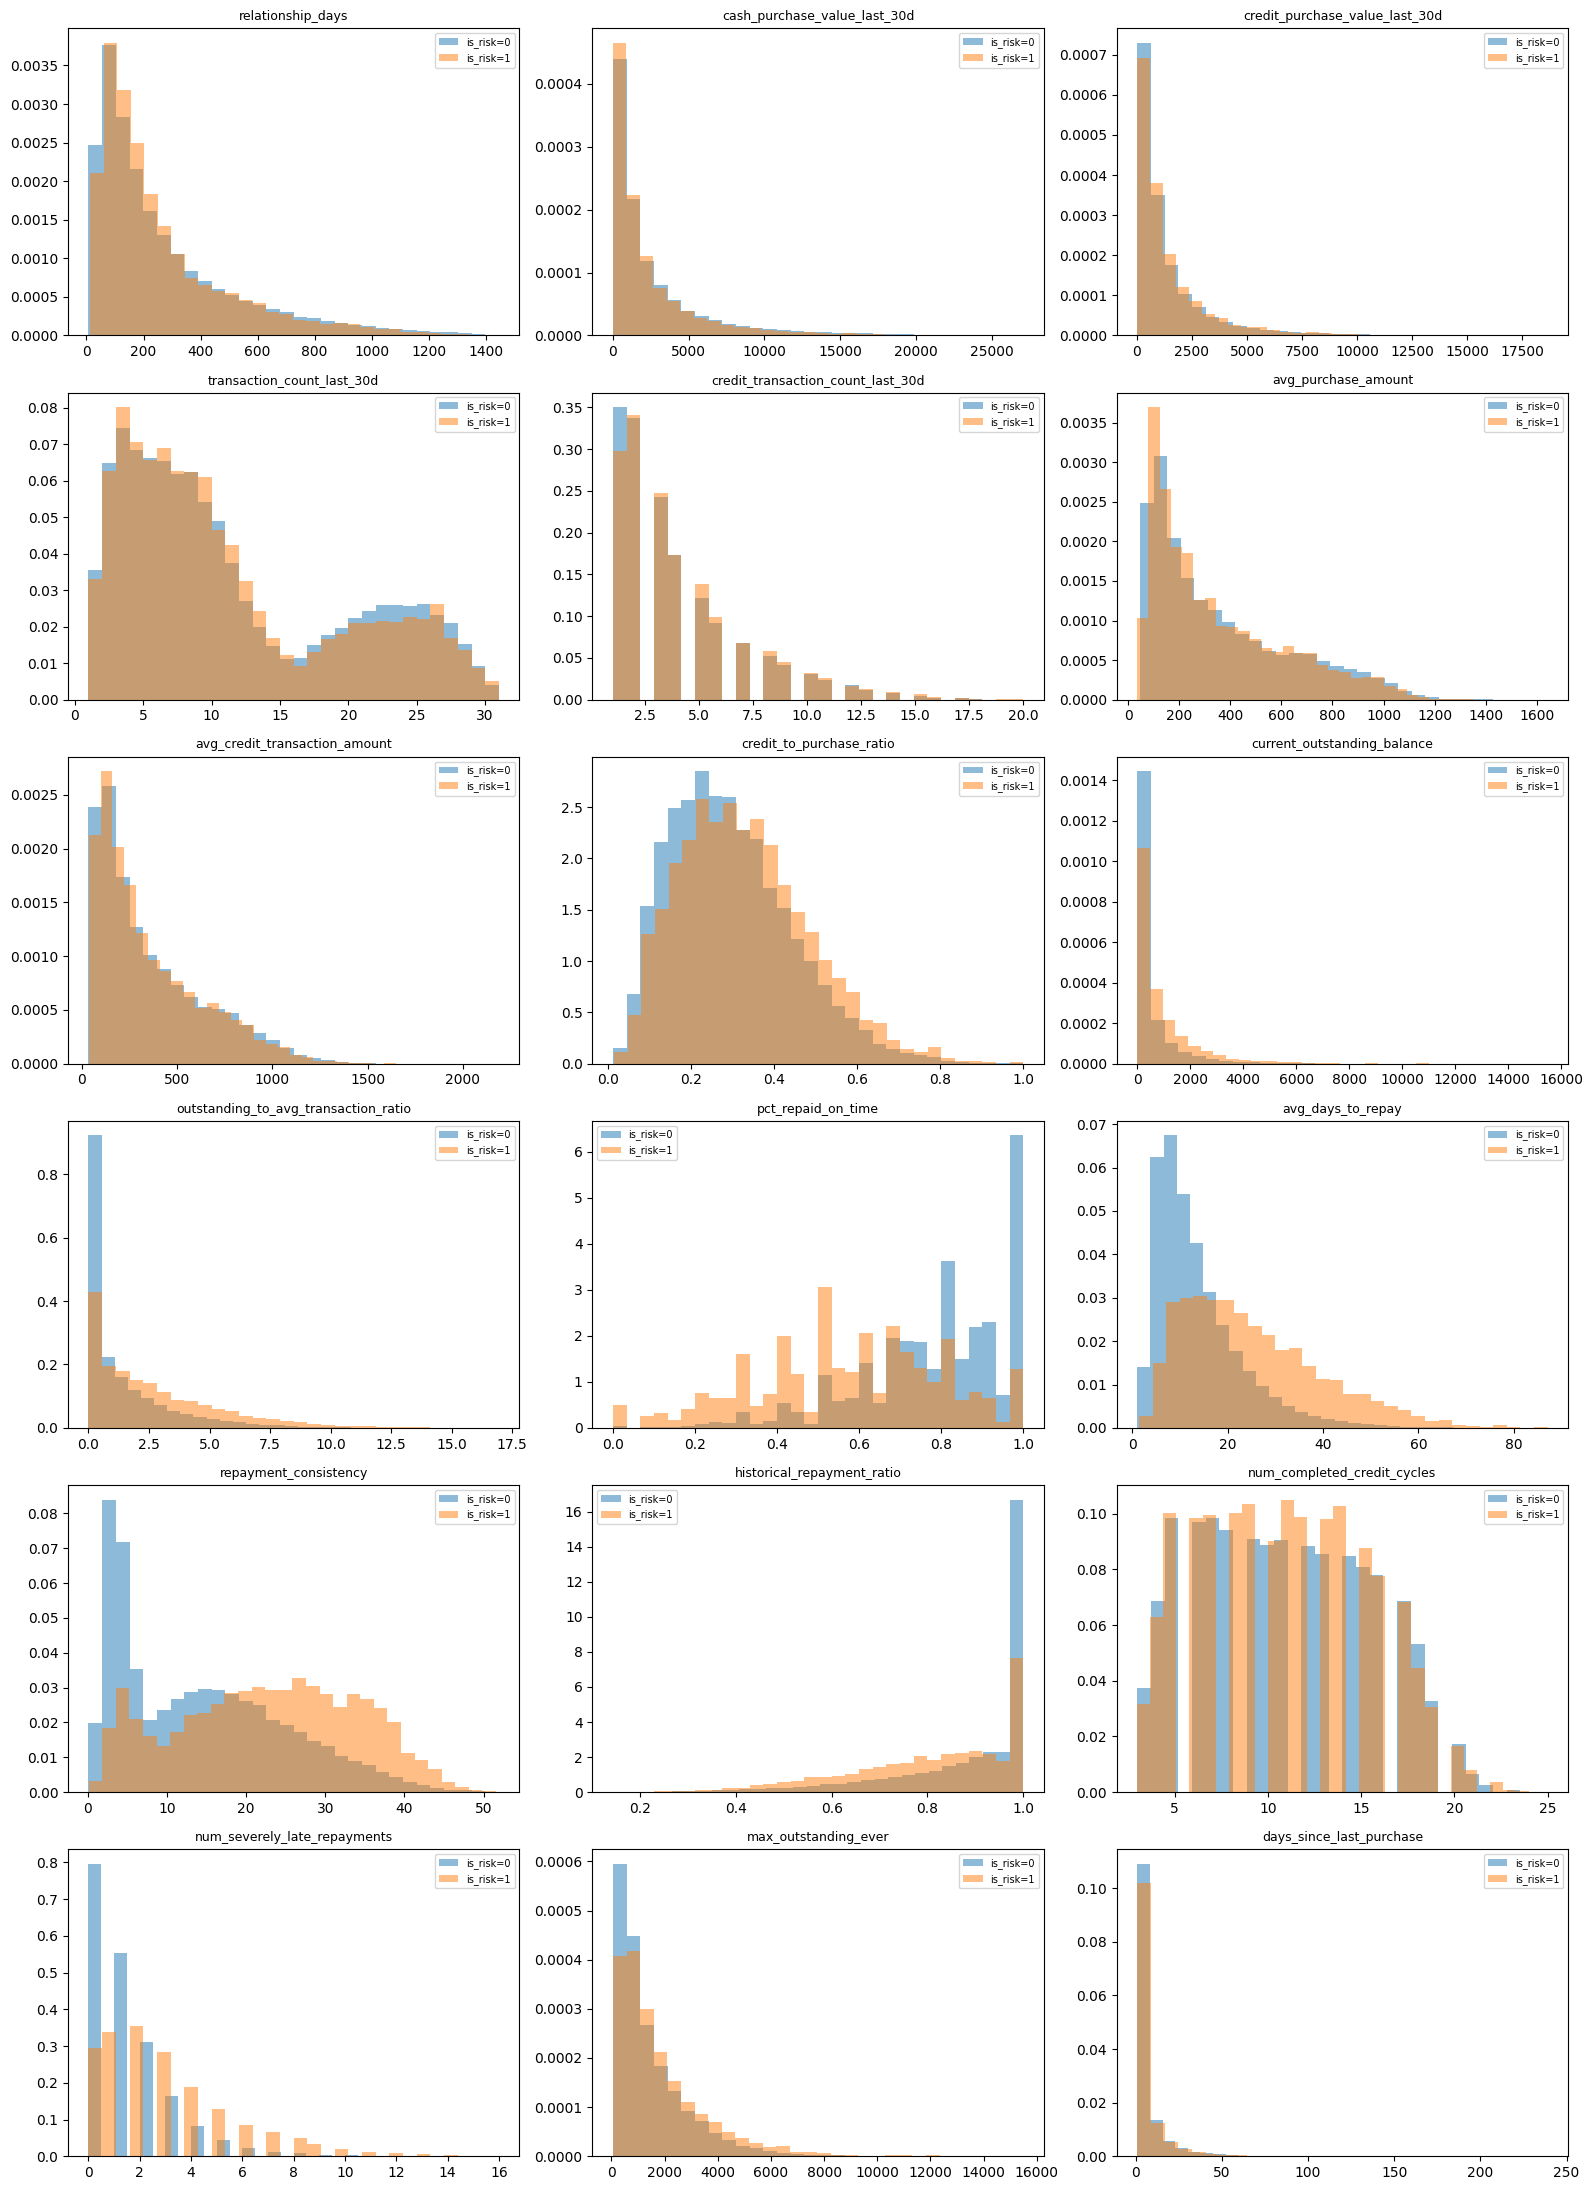

In [5]:
# Feature distributions, split by target - sanity check against the logistic
# label formula above (outstanding balance, pct_repaid_on_time, credit_to_purchase_ratio,
# repayment_consistency and num_severely_late_repayments should visibly separate the classes).
fig, axes = plt.subplots(6, 3, figsize=(16, 22))
for ax, col in zip(axes.ravel(), FEATURE_COLUMNS):
    for label, group in df.groupby(TARGET_COLUMN)[col]:
        ax.hist(group, bins=30, alpha=0.5, density=True, label=f"is_risk={label}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

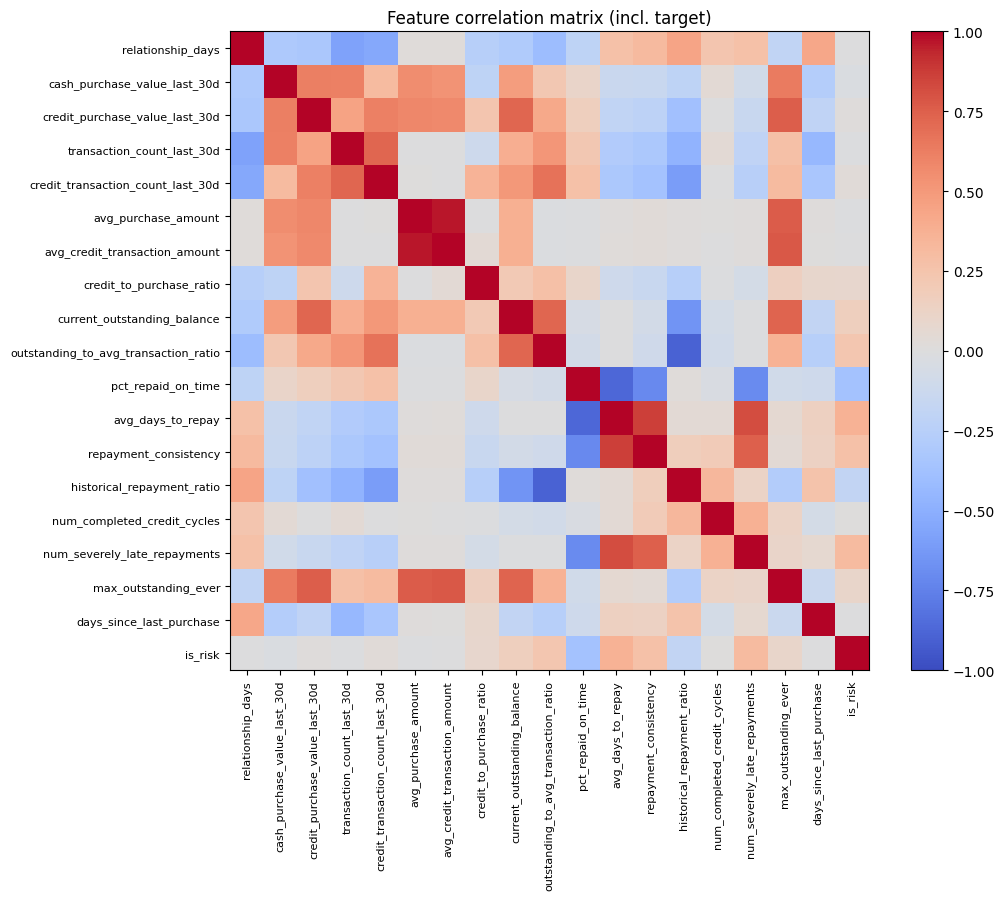

is_risk                                 1.000000
avg_days_to_repay                       0.366113
num_severely_late_repayments            0.306622
repayment_consistency                   0.268727
outstanding_to_avg_transaction_ratio    0.227111
current_outstanding_balance             0.158499
max_outstanding_ever                    0.098339
credit_to_purchase_ratio                0.080539
credit_transaction_count_last_30d       0.024638
credit_purchase_value_last_30d          0.010316
num_completed_credit_cycles             0.004828
days_since_last_purchase               -0.003460
avg_credit_transaction_amount          -0.004662
relationship_days                      -0.006607
avg_purchase_amount                    -0.009616
transaction_count_last_30d             -0.014516
cash_purchase_value_last_30d           -0.024871
historical_repayment_ratio             -0.184421
pct_repaid_on_time                     -0.366490
Name: is_risk, dtype: float64

In [6]:
# Correlation heatmap
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im)
plt.title("Feature correlation matrix (incl. target)")
plt.tight_layout()
plt.show()

corr[TARGET_COLUMN].sort_values(ascending=False)